<a href="https://colab.research.google.com/github/hanxskuy/Skripshuy/blob/main/Skripshit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
andrewmvd_liver_tumor_segmentation_path = kagglehub.dataset_download('andrewmvd/liver-tumor-segmentation')
andrewmvd_liver_tumor_segmentation_part_2_path = kagglehub.dataset_download('andrewmvd/liver-tumor-segmentation-part-2')

print('Data source import complete.')

100%|██████████| 4.84G/4.84G [00:56<00:00, 92.0MB/s]

Extracting files...


100%|██████████| 10.8G/10.8G [02:00<00:00, 96.6MB/s]

Extracting files...


Data source import complete.


In [ ]:
import os

print("Part 1:")
print(os.listdir(andrewmvd_liver_tumor_segmentation_path))

print("\nPart 2:")
print(os.listdir(andrewmvd_liver_tumor_segmentation_part_2_path))

Part 1:
['segmentations', 'volume_pt5', 'volume_pt2', 'volume_pt1', 'volume_pt4', 'volume_pt3']

Part 2:
['volume_pt6', 'volume_pt8']


In [ ]:
seg_path = andrewmvd_liver_tumor_segmentation_path + "/segmentations"
print(os.listdir(seg_path)[:10])  # tampilkan 10 file pertama

['segmentation-2.nii', 'segmentation-115.nii', 'segmentation-3.nii', 'segmentation-63.nii', 'segmentation-50.nii', 'segmentation-66.nii', 'segmentation-112.nii', 'segmentation-92.nii', 'segmentation-23.nii', 'segmentation-43.nii']


In [ ]:
vol_path = andrewmvd_liver_tumor_segmentation_path + "/volume_pt1"
print(os.listdir(vol_path)[:10])

['volume-9.nii', 'volume-3.nii', 'volume-4.nii', 'volume-5.nii', 'volume-10.nii', 'volume-1.nii', 'volume-0.nii', 'volume-2.nii', 'volume-8.nii', 'volume-6.nii']


In [ ]:
import os
import shutil

base_output = "/content/nnUNet_raw/Dataset001_LiverTumor"

imagesTr = os.path.join(base_output, "imagesTr")
labelsTr = os.path.join(base_output, "labelsTr")

os.makedirs(imagesTr, exist_ok=True)
os.makedirs(labelsTr, exist_ok=True)

print("Folder nnU-Net berhasil dibuat!")

Folder nnU-Net berhasil dibuat!


In [ ]:
import glob

# Ambil volume dari part 1
volume_folders_1 = glob.glob(andrewmvd_liver_tumor_segmentation_path + "/volume_pt*")

# Ambil volume dari part 2
volume_folders_2 = glob.glob(andrewmvd_liver_tumor_segmentation_part_2_path + "/volume_pt*")

all_volumes = []

for folder in volume_folders_1 + volume_folders_2:
    files = glob.glob(folder + "/*.nii")
    all_volumes.extend(files)

print("Total volume ditemukan:", len(all_volumes))

Total volume ditemukan: 131


In [ ]:
seg_1 = glob.glob(andrewmvd_liver_tumor_segmentation_path + "/segmentations/*.nii")
seg_2 = glob.glob(andrewmvd_liver_tumor_segmentation_part_2_path + "/segmentations/*.nii")

all_segmentations = seg_1 + seg_2

print("Total segmentation ditemukan:", len(all_segmentations))

Total segmentation ditemukan: 131


In [ ]:
!rm -rf /root/.cache/kagglehub

# **Mengambil Dataset Part 1**

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "andrewmvd/liver-tumor-segmentation"
)

print("Dataset tersimpan di:", dataset_path)

100%|██████████| 4.84G/4.84G [00:44<00:00, 116MB/s]

Extracting files...


Dataset tersimpan di: /root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5


# **Import Library OS**

In [ ]:
import os

print("Isi folder utama:")
print(os.listdir(dataset_path))

Isi folder utama:
['segmentations', 'volume_pt5', 'volume_pt2', 'volume_pt1', 'volume_pt4', 'volume_pt3']


# **Menampilkan Isi Folder Dataset**

In [ ]:
import os

total_volume = 0

for folder in os.listdir(dataset_path):
    if "volume" in folder:
        folder_path = os.path.join(dataset_path, folder)
        count = len(os.listdir(folder_path))
        print(folder, ":", count)
        total_volume += count

print("\nTOTAL VOLUME:", total_volume)

seg_path = os.path.join(dataset_path, "segmentations")
print("TOTAL SEGMENTATION:", len(os.listdir(seg_path)))

volume_pt5 : 10
volume_pt2 : 10
volume_pt1 : 11
volume_pt4 : 10
volume_pt3 : 10

TOTAL VOLUME: 51
TOTAL SEGMENTATION: 131


# **Mengambil dan Mengurutkan File Dataset**

In [ ]:
volumes = []
for folder in os.listdir(dataset_path):
    if "volume" in folder:
        folder_path = os.path.join(dataset_path, folder)
        volumes += os.listdir(folder_path)

volumes = sorted(volumes)
segmentations = sorted(os.listdir(os.path.join(dataset_path, "segmentations")))

print("Contoh volume:", volumes[:5])
print("Contoh segmentation:", segmentations[:5])

Contoh volume: ['volume-0.nii', 'volume-1.nii', 'volume-10.nii', 'volume-11.nii', 'volume-12.nii']
Contoh segmentation: ['segmentation-0.nii', 'segmentation-1.nii', 'segmentation-10.nii', 'segmentation-100.nii', 'segmentation-101.nii']


In [ ]:
!pip install nibabel matplotlib

# **Mengunduh Dataset dari Kaggle**

In [ ]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "andrewmvd/liver-tumor-segmentation"
)

print(dataset_path)

/root/.cache/kagglehub/datasets/andrewmvd/liver-tumor-segmentation/versions/5


# **Membaca dan Menampilkan CT Scan serta Mask**

Shape: (512, 512, 75)


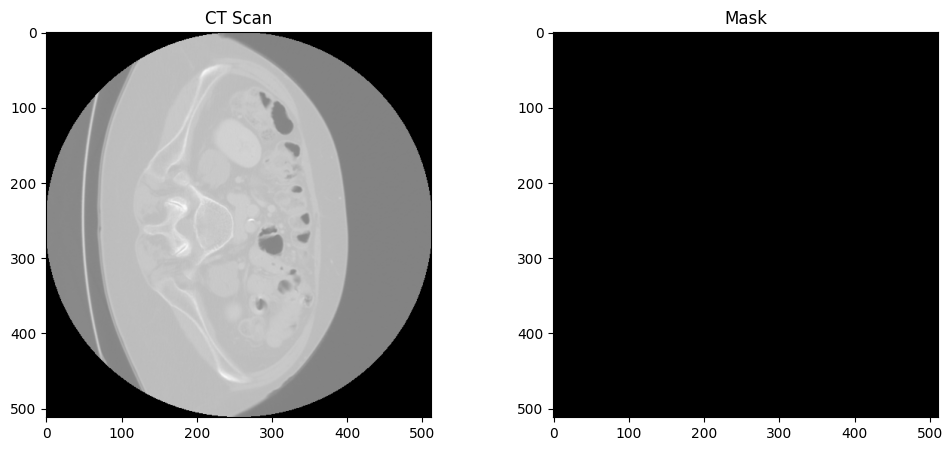

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

# Ambil semua volume
volume_files = []
for folder in os.listdir(dataset_path):
    if "volume" in folder:
        folder_path = os.path.join(dataset_path, folder)
        for file in os.listdir(folder_path):
            volume_files.append(os.path.join(folder_path, file))

volume_files = sorted(volume_files)

seg_files = sorted(os.listdir(os.path.join(dataset_path, "segmentations")))
seg_files = [os.path.join(dataset_path, "segmentations", f) for f in seg_files]

# Ambil sample pertama
volume_sample = volume_files[0]
seg_sample = seg_files[0]

# Load
volume = nib.load(volume_sample)
seg = nib.load(seg_sample)

volume_data = volume.get_fdata()
seg_data = seg.get_fdata()

print("Shape:", volume_data.shape)

# Tampilkan slice tengah
slice_idx = volume_data.shape[2] // 2

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(volume_data[:,:,slice_idx], cmap='gray')
plt.title("CT Scan")

plt.subplot(1,2,2)
plt.imshow(seg_data[:,:,slice_idx], cmap='gray')
plt.title("Mask")

plt.show()

# **Mencari Slice yang Mengandung Tumor**

In [ ]:
import numpy as np

# Cari slice yang ada nilai selain 0
tumor_slices = []

for i in range(seg_data.shape[2]):
    if np.sum(seg_data[:,:,i]) > 0:
        tumor_slices.append(i)

print("Jumlah slice ada tumor:", len(tumor_slices))
print("Contoh slice:", tumor_slices[:10])

Jumlah slice ada tumor: 29
Contoh slice: [45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


# **Menampilkan CT Scan dan Mask Tumor**

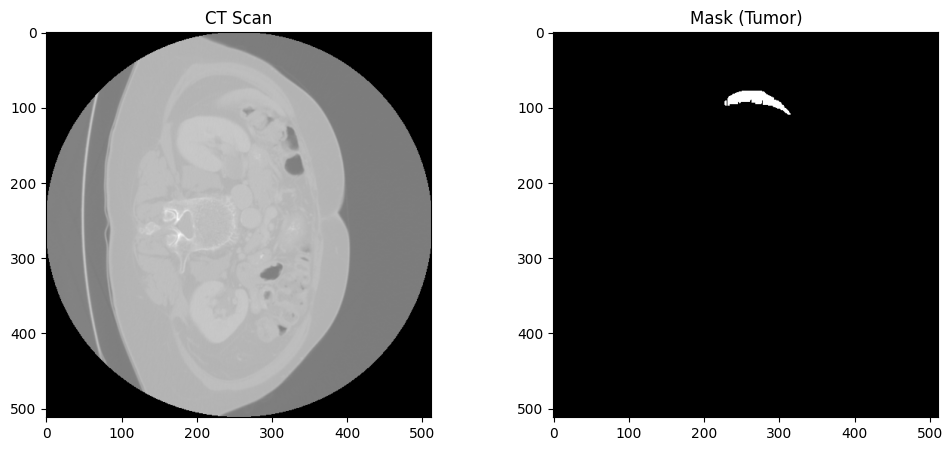

In [ ]:
slice_idx = tumor_slices[0]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(volume_data[:,:,slice_idx], cmap='gray')
plt.title("CT Scan")

plt.subplot(1,2,2)
plt.imshow(seg_data[:,:,slice_idx], cmap='gray')
plt.title("Mask (Tumor)")

plt.show()

# **Overlay Tumor pada CT Scan**

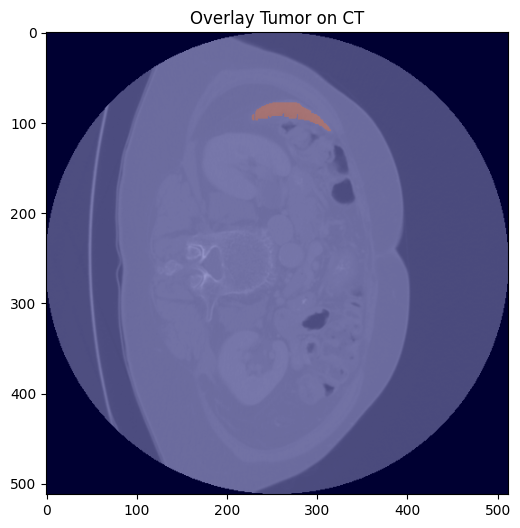

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(volume_data[:,:,slice_idx], cmap='gray')
plt.imshow(seg_data[:,:,slice_idx], cmap='jet', alpha=0.4)

plt.title("Overlay Tumor on CT")
plt.show()

# **Melihat Nilai Label pada Mask**

In [ ]:
import numpy as np

print("Nilai unik dalam mask:")
print(np.unique(seg_data))

Nilai unik dalam mask:
[0. 1. 2.]


# **Perhitungan Jumlah Voxel Tumor dan Liver**

In [ ]:
tumor_voxel = np.sum(seg_data == 2)
liver_voxel = np.sum(seg_data == 1)
background_voxel = np.sum(seg_data == 0)

print("Voxel Tumor:", tumor_voxel)
print("Voxel Liver:", liver_voxel)
print("Voxel Background:", background_voxel)

Voxel Tumor: 2591
Voxel Liver: 550036
Voxel Background: 19108173


# **Mengetahui Resolusi Voxel CT Scan**

In [ ]:
voxel_size = volume.header.get_zooms()
print("Ukuran voxel (mm):", voxel_size)

Ukuran voxel (mm): (np.float32(0.703125), np.float32(0.703125), np.float32(5.0))


# **Perhitungan Volume Tumor**

In [ ]:
voxel_volume_mm3 = 0.703125 * 0.703125 * 5  # mm^3 per voxel
tumor_volume_mm3 = tumor_voxel * voxel_volume_mm3
print("Volume tumor (mm^3):", tumor_volume_mm3)

Volume tumor (mm^3): 6404.754638671875


# **Konversi Volume Tumor ke cm³**

In [ ]:
tumor_volume_cm3 = tumor_volume_mm3 / 1000
print("Volume tumor (cm^3):", tumor_volume_cm3)

Volume tumor (cm^3): 6.404754638671875


In [ ]:
!pip install pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.6/145.6 MB 7.6 MB/s eta 0:00:00


In [ ]:
!pip install plotly scikit-image

In [ ]:
import numpy as np
from skimage import measure
import plotly.graph_objects as go

# Mask tumor
tumor_mask = seg_data == 2  # True = tumor voxel

## Punya Putri

In [ ]:
import os
import numpy as np
import cv2
from scipy import ndimage
import matplotlib.pyplot as plt

In [ ]:
def load_patient(folder_path):
    slices = []

    files = sorted(os.listdir(folder_path))

    for file in files:
        img = cv2.imread(os.path.join(folder_path, file), 0)
        slices.append(img)

    volume = np.stack(slices)

    # Binarisasi (tumor = 1)
    volume = (volume > 0).astype(np.uint8)

    return volume

In [ ]:
def count_tumors(volume):
    labeled, num_features = ndimage.label(volume)
    return labeled, num_features

In [ ]:
def get_centroids(labeled):
    objects = ndimage.find_objects(labeled)
    centroids = []

    for i, obj in enumerate(objects):
        region = (labeled[obj] == (i+1))
        coords = np.argwhere(region)

        centroid = coords.mean(axis=0)
        centroids.append(centroid)

    return centroids

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'nnUNet_raw', 'sample_data']
